# __Futures/Spot HBT Step-by-Step Notebook__

This notebook calls functions from `future_spot/scripts/run_hbt_daily_full_market_backtest.py` directly, one stage per cell. It keeps the CLI pipeline visible while ending with summary tables, charts, and three-timeline latency observation.


In [6]:
from argparse import Namespace
from pathlib import Path
import importlib
import logging
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
WORKSPACE_ROOT = PROJECT_ROOT.parent
SCRIPT_DIR = PROJECT_ROOT / "scripts"

for path in (SCRIPT_DIR, PROJECT_ROOT, WORKSPACE_ROOT):
    text = str(path)
    if text not in sys.path:
        sys.path.insert(0, text)

import arbitrage.hbt_backtest as hbt_backtest
import run_hbt_daily_full_market_backtest as daily_hbt

hbt_backtest = importlib.reload(hbt_backtest)
daily_hbt = importlib.reload(daily_hbt)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
print(f"project_root={PROJECT_ROOT}")
print(f"workspace_root={WORKSPACE_ROOT}")


project_root=/home/zoufuc/hftbacktest/future_spot
workspace_root=/home/zoufuc/hftbacktest


## __Parameters and Configuration__

### __Parameters__

Keep these paths Linux/WSL friendly. Windows-style paths such as `Z:\...` will not open correctly from Linux Python.

Choose the spot daily tick source with `DAILY_TICK_DATA_SOURCE`:

- `"csv"`: read daily tick CSV files from `/mnt/z/FubunData/tick_csv/twstock_{date_nodash}.csv`; this avoids `data_platform_client`.
- `"data_platform"`: use the legacy DataAPI path through `data_platform_base`.

This notebook is configured for latency observation with explicit order/response/feed latency parameters.


In [7]:
DAILY_TICK_DATA_SOURCE = "csv"  # "csv" or "data_platform"
SPOT_INPUT_CSV_TEMPLATE = "/mnt/z/FubunData/tick_csv/twstock_{date_nodash}.csv"
DATA_PLATFORM_BASE = "/mnt/z/數據平台"

if DAILY_TICK_DATA_SOURCE not in {"csv", "data_platform"}:
    raise ValueError("DAILY_TICK_DATA_SOURCE must be csv or data_platform")

spot_input_csv_template = SPOT_INPUT_CSV_TEMPLATE if DAILY_TICK_DATA_SOURCE == "csv" else ""

args = Namespace(
    start_date="2026-05-21",
    end_date="2026-05-26",
    base_config=PROJECT_ROOT / "arbitrage_config_base.json",
    calendar=PROJECT_ROOT / "Calendar.csv",
    stockinfo=PROJECT_ROOT / "stockinfo.csv",
    output_dir=PROJECT_ROOT / "output" / "hbt_daily_full_market_20260521_20260526_latency_10ms",

    futures_parquet_template="/mnt/z/ticks_parquet_stock_future/{ldate}.parquet",
    twse_daytrade_template="/mnt/z/TWSE/每日個股狀況/{date_nodash}.csv",
    tpex_daytrade_template="/mnt/z/TPEX/每日個股狀況/{date_nodash}.csv",
    twse_daily_template="/mnt/z/TWSE/每日資料/{ldate_nodash}.ftr",
    tpex_daily_template="/mnt/z/TPEX/每日資料/{ldate_nodash}.ftr",
    spot_input_csv_template=spot_input_csv_template,
    data_platform_base=DATA_PLATFORM_BASE,
    event_futures_parquet_dir=Path("/mnt/z/ticks_parquet_stock_future"),

    build_session_start="08:45:00",
    build_session_end="13:45:00",
    min_future_volume=1000,
    min_stock_volume=20_000_000,
    required_unit=2000,
    name_template="{spot_symbol}_{future_symbol}",
    rebuild_daily_configs=False,

    session_start="09:00:00",
    session_end="13:25:00",
    pair_name=[],
    max_pairs=None,

    no_convert_missing_event_data=False,
    rebuild_event_data=False,
    conversion_qa_sample_rows=1000,

    first_leg="future",
    step_ms=1000.0,
    order_latency_ms=10.0,              # 下單延遲
    response_latency_ms=10.0,           # 回報延遲    
    feed_latency_offset_ms=10.0,        # 行情延遲
    second_leg_delay_ms=0.0,            # 視為 IDC 計算時間
    post_first_feed_wait="spot",        # 第一腿回報後等 spot feed refresh 再判斷第二腿
    post_first_feed_timeout_ms=5000.0,
    post_first_feed_poll_ms=1.0,
    response_timeout_ms=50.0,
    max_steps=None,
    max_trades_per_pair=None,
    record_market_every_steps=1,
    rebuild_hbt_results=True,
    queue_model="risk_adverse",
    entry_threshold_pct=None,
    exit_threshold_pct=None,
    min_effective_tick_multiple=None,
    min_second_leg_adjusted_basis_pct=None,
    no_second_leg_profit_check=False,
    no_flatten=False,

    continue_on_error=False,
    log_level="INFO",
)

args.output_dir.mkdir(parents=True, exist_ok=True)
print(args.output_dir)
print(f"daily_tick_data_source={DAILY_TICK_DATA_SOURCE}")
print(f"spot_input_csv_template={args.spot_input_csv_template or None}")
print(f"post_first_feed_wait={args.post_first_feed_wait}, timeout_ms={args.post_first_feed_timeout_ms}")


/home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms
daily_tick_data_source=csv
spot_input_csv_template=/mnt/z/FubunData/tick_csv/twstock_{date_nodash}.csv
post_first_feed_wait=spot, timeout_ms=5000.0


### __Build Daily Pair Config Universe__

Calls `build_daily_pair_records()`, then writes the same CSVs as the CLI.


In [8]:
trade_dates = daily_hbt.select_trade_dates(args.calendar, args.start_date, args.end_date)

records, build_status = daily_hbt.build_daily_pair_records(args, trade_dates)
daily_hbt.write_csv(build_status, args.output_dir / "daily_config_build_status.csv")

pair_universe = daily_hbt.pair_universe_frame(records)
daily_hbt.write_csv(pair_universe, args.output_dir / "daily_pair_universe.csv")

2026-07-06 15:35:45,502 INFO wrote 4 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/daily_config_build_status.csv
2026-07-06 15:35:45,506 INFO wrote 195 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/daily_pair_universe.csv


In [9]:
# Pair universe summary
# pair_universe.head(20)

---


## __HBT Backtest__


### __Build / Reuse HBT Event Data__

Calls `build_event_data()`. With `rebuild_event_data=False`, existing `.npz` files are reused.


In [10]:
event_paths, conversion_status = daily_hbt.build_event_data(args, records)
daily_hbt.write_csv(conversion_status, args.output_dir / "conversion_status.csv")

2026-07-06 15:35:45,542 INFO wrote 195 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/conversion_status.csv


### __HBT Settings Audit__

Calls `hbt_settings_frame()` to inspect tick sizes, event rows, and basic event counts before running HBT.


In [11]:
settings = daily_hbt.hbt_settings_frame(args, records, event_paths)
daily_hbt.write_csv(settings, args.output_dir / "hbt_settings.csv")

settings.groupby("leg").agg(
    assets=("symbol", "count"),
    rows=("rows", "sum"),
    depth_events=("depth_events", "sum"),
    trade_events=("trade_events", "sum"),
)

2026-07-06 15:39:04,924 INFO wrote 390 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/hbt_settings.csv


,assets,rows,depth_events,trade_events
leg,,,,
future,195,67586762,67287530,299232
spot,195,196718977,193790771,2928206


### __Run HBT Backtests__

Calls `run_backtests()`. This is the expensive step. It returns in-memory DataFrames and then writes the same output CSVs as the CLI, including `latency_all_daily_pairs.csv`.

> 這裡跑四天全市場大概 10 分鐘

In [12]:
pair_results, summary, trades, market, latency, run_errors = daily_hbt.run_or_load_backtests(args, records, event_paths)

if args.post_first_feed_wait != "none" and "post_first_feed_wait" not in summary.columns:
    raise RuntimeError("Loaded old HBT code/results: summary is missing post_first_feed_wait. Restart/reload notebook and rerun HBT.")

daily_hbt.write_csv(summary, args.output_dir / "summary_all_daily_pairs.csv")
daily_hbt.write_csv(trades, args.output_dir / "trades_all_daily_pairs.csv")
daily_hbt.write_csv(market, args.output_dir / "market_all_daily_pairs.csv")
daily_hbt.write_csv(latency, args.output_dir / "latency_all_daily_pairs.csv")
daily_hbt.write_csv(run_errors, args.output_dir / "run_errors.csv")

2026-07-06 15:43:04,176 INFO wrote 195 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/summary_all_daily_pairs.csv
2026-07-06 15:43:09,162 INFO wrote 208374 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/trades_all_daily_pairs.csv
2026-07-06 15:43:43,782 INFO wrote 2134155 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/market_all_daily_pairs.csv
2026-07-06 15:43:43,915 INFO wrote 5537 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/latency_all_daily_pairs.csv
2026-07-06 15:43:43,917 INFO wrote 0 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/run_errors.csv


In [45]:
summary = pd.read_csv(args.output_dir / "summary_all_daily_pairs.csv")  
# print(summary[summary['filled_pairs'] > 35])        # 列出 filled_pairs 超過 35 的 pair

In [14]:
# print(pd.read_csv(args.output_dir / "trades_all_daily_pairs.csv").head(10))

In [43]:
# print(pd.read_csv(args.output_dir / "market_all_daily_pairs.csv").head(10))

In [16]:
# print(pd.read_csv(args.output_dir / "latency_all_daily_pairs.csv").head(10))

In [17]:
# print(pd.read_csv(args.output_dir / "run_errors.csv").head(20))

### __Build Entry / Exit Tables__

Calls `build_entry_exit_outputs()` and writes compact per-pair entry / execution files.


In [18]:
entry_exit_by_pair, entry_exit_all, entry_exit_index = daily_hbt.build_entry_exit_outputs(pair_results, records)

daily_hbt.write_csv(entry_exit_all, args.output_dir / "entry_exit_all_daily_pairs.csv")
daily_hbt.write_csv(entry_exit_index, args.output_dir / "entry_exit_index.csv")
daily_hbt.write_entry_exit_by_pair(entry_exit_by_pair, args.output_dir / "entry_exit_by_pair")


2026-07-06 15:43:50,163 INFO wrote 411551 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/entry_exit_all_daily_pairs.csv
2026-07-06 15:43:50,167 INFO wrote 195 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/entry_exit_index.csv
2026-07-06 15:43:50,169 INFO wrote 0 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/entry_exit_by_pair/2026-05-21_1303_CAFE6.csv
2026-07-06 15:43:50,174 INFO wrote 0 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/entry_exit_by_pair/2026-05-21_2324_CGFE6.csv
2026-07-06 15:43:50,175 INFO wrote 0 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms/entry_exit_by_pair/2026-05-21_2409_CHFE6.csv
2026-07-06 15:43:50,176 INFO wrote 0 rows to /home/zoufuc/hftbacktest/future_spot/output/hbt_dai

In [19]:
entry_exit_index = pd.read_csv(args.output_dir / "entry_exit_index.csv")
print(entry_exit_index[entry_exit_index["entry_execution_rows"] > 3000])    # 列出 entry_execution_rows 超過 3000 的 pair

     trade_date                 run_key   pair_name   rows  entry_signal_rows  entry_execution_rows  exit_execution_rows
95   2026-05-25  2026-05-25::2408_CYFF6  2408_CYFF6   6477               3227                  3250                    0
107  2026-05-25  2026-05-25::2313_FTFF6  2313_FTFF6  21622              10786                 10836                    0
111  2026-05-25  2026-05-25::2449_GRFF6  2449_GRFF6   6823               3407                  3416                    0
113  2026-05-25  2026-05-25::2485_GZFF6  2485_GZFF6  17788               8751                  9037                    0
115  2026-05-25  2026-05-25::3006_IIFF6  3006_IIFF6  14485               7180                  7295                   10
119  2026-05-25  2026-05-25::3673_JNFF6  3673_JNFF6   6884               3407                  3477                    0
121  2026-05-25  2026-05-25::6285_KGFF6  6285_KGFF6  10021               4975                  5046                    0
125  2026-05-25  2026-05-25::232

---

## __Results__

### __Estimated Profit by Symbol / Pair Aggregate__

In [ ]:
summary = pd.read_csv(args.output_dir / "summary_all_daily_pairs.csv")

symbol_profit = (
    summary
    .groupby("spot_symbol", as_index=False)
    .agg(
        trade_days=("trade_date", "nunique"),
        pair_names=("pair_name", "nunique"),
        estimated_profit=("realized_pnl", "sum"),
        avg_daily_profit=("realized_pnl", "mean"),
        filled_pairs=("filled_pairs", "sum"),
        second_leg_failures=("second_leg_failures", "sum"),
        flatten_count=("flatten_count", "sum"),
        final_quantity_abs=("final_quantity", lambda s: s.abs().sum()),
    )
    .sort_values("estimated_profit", ascending=False)
)

symbol_profit.head(30)


,spot_symbol,trade_days,pair_names,estimated_profit,avg_daily_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity_abs
40,3037,4,2,"105,759.6480","26,439.9120",30,0,0,10.0000
28,2455,3,2,"43,553.9080","14,517.9693",30,0,0,10.0000
63,8046,1,1,"31,742.0220","31,742.0220",18,1,0,10.0000
24,2408,4,2,"29,298.5660","7,324.6415",56,0,0,20.0000
50,4958,4,2,"19,664.4420","4,916.1105",30,0,0,10.0000
29,2481,4,2,"19,016.4380","4,754.1095",52,0,0,10.0000
14,2344,4,2,"18,306.0020","4,576.5005",32,0,0,0.0000
57,6271,2,1,"17,838.0550","8,919.0275",20,1,0,0.0000
44,3481,4,2,"17,738.2797","4,434.5699",62,0,0,20.0000
18,2367,3,1,"17,576.2788","5,858.7596",50,0,0,10.0000


In [46]:
print(symbol_profit[symbol_profit["second_leg_failures"] > 0])        # 列出 second_leg_failures 超過 0 的 pair

    spot_symbol  trade_days  pair_names  estimated_profit  avg_daily_profit  filled_pairs  second_leg_failures  flatten_count  final_quantity_abs
63         8046           1           1       31,742.0220       31,742.0220            18                    1              0             10.0000
57         6271           2           1       17,838.0550        8,919.0275            20                    1              0              0.0000
1          1605           4           1        3,243.8701          810.9675            40                    1              0             20.0000
64         8150           2           1        1,141.5709          570.7854            22                    1              0             20.0000
52         5425           4           2         -200.0000          -50.0000            30                    1              1             30.0000


2026-07-06 15:43:56,671 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:56,672 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:56,681 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:56,682 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:56,690 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

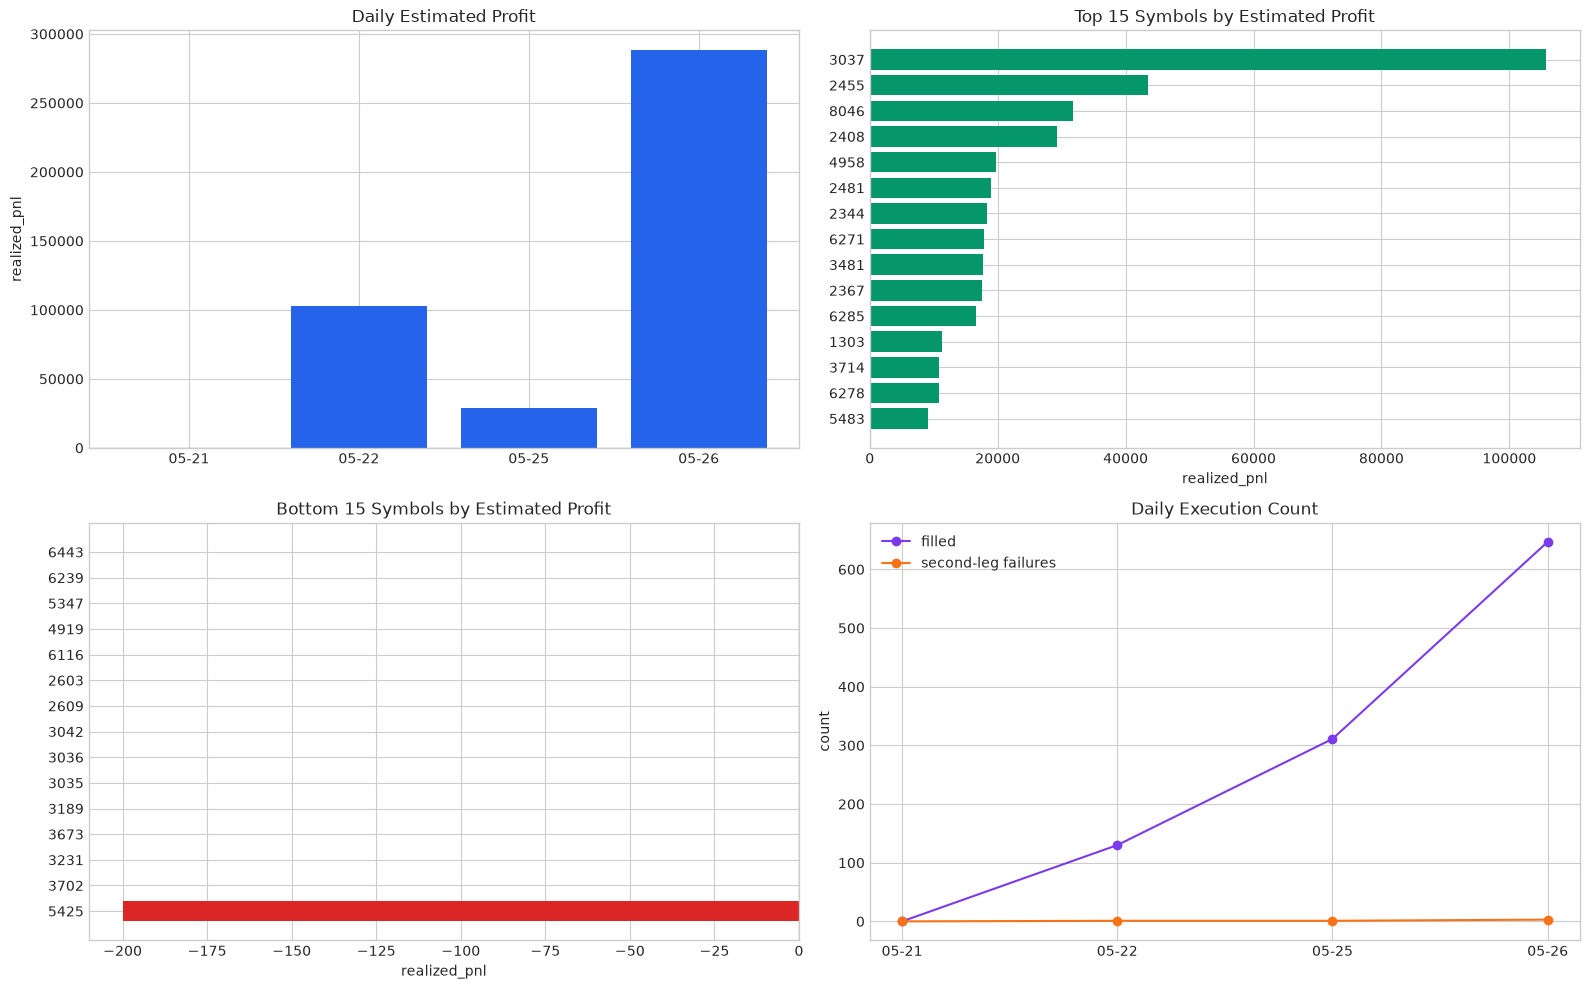

In [21]:
plt.style.use("seaborn-v0_8-whitegrid")
summary_plot = summary.copy()
summary_plot["trade_date"] = pd.to_datetime(summary_plot["trade_date"])

daily = summary_plot.groupby("trade_date", as_index=False).agg(
    estimated_profit=("realized_pnl", "sum"),
    filled_pairs=("filled_pairs", "sum"),
    second_leg_failures=("second_leg_failures", "sum"),
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(daily["trade_date"].dt.strftime("%m-%d"), daily["estimated_profit"], color="#2563eb")
axes[0, 0].axhline(0, color="#111827", linewidth=0.8)
axes[0, 0].set_title("Daily Estimated Profit")
axes[0, 0].set_ylabel("realized_pnl")

top = symbol_profit.head(15).sort_values("estimated_profit")
axes[0, 1].barh(top["spot_symbol"].astype(str), top["estimated_profit"], color="#059669")
axes[0, 1].set_title("Top 15 Symbols by Estimated Profit")
axes[0, 1].set_xlabel("realized_pnl")

bottom = symbol_profit.tail(15).sort_values("estimated_profit")
axes[1, 0].barh(bottom["spot_symbol"].astype(str), bottom["estimated_profit"], color="#dc2626")
axes[1, 0].axvline(0, color="#111827", linewidth=0.8)
axes[1, 0].set_title("Bottom 15 Symbols by Estimated Profit")
axes[1, 0].set_xlabel("realized_pnl")

axes[1, 1].plot(daily["trade_date"].dt.strftime("%m-%d"), daily["filled_pairs"], marker="o", color="#7c3aed", label="filled")
axes[1, 1].plot(daily["trade_date"].dt.strftime("%m-%d"), daily["second_leg_failures"], marker="o", color="#f97316", label="second-leg failures")
axes[1, 1].set_title("Daily Execution Count")
axes[1, 1].set_ylabel("count")
axes[1, 1].legend()

fig.tight_layout()
plt.show()


### __Estimated Profit by Symbol / Pair by Date__

In [22]:
pair_profit = summary.merge(
    pair_universe[["run_key", "entry_threshold_pct", "min_effective_tick_multiple", "spot_order_qty", "future_order_qty"]],
    on="run_key",
    how="left",
).rename(columns={"realized_pnl": "estimated_profit"})

pair_profit = pair_profit[[
    "trade_date", "pair_name", "spot_symbol", "future_symbol",
    "estimated_profit", "filled_pairs", "second_leg_failures", "flatten_count",
    "final_quantity", "entry_threshold_pct", "min_effective_tick_multiple",
    "spot_order_qty", "future_order_qty",
]].sort_values("estimated_profit", ascending=False)

pair_profit.head(50)

,trade_date,pair_name,spot_symbol,future_symbol,estimated_profit,filled_pairs,second_leg_failures,flatten_count,final_quantity,entry_threshold_pct,min_effective_tick_multiple,spot_order_qty,future_order_qty
68,2026-05-22,3037_IRFF6,3037,IRFF6,"105,759.6480",30,0,0,10.0000,0.0130,2.0000,2000,1
162,2026-05-26,2455_GUFF6,2455,GUFF6,"43,553.9080",20,0,0,0.0000,0.0130,2.0000,2000,1
179,2026-05-26,8046_LYFF6,8046,LYFF6,"31,742.0220",18,1,0,10.0000,0.0130,2.0000,2000,1
146,2026-05-26,2408_CYFF6,2408,CYFF6,"29,298.5660",46,0,0,10.0000,0.0130,2.0000,2000,1
171,2026-05-26,6271_KDFF6,6271,KDFF6,"20,838.0550",20,0,0,0.0000,0.0130,2.0000,2000,1
178,2026-05-26,4958_LUFF6,4958,LUFF6,"19,664.4420",20,0,0,0.0000,0.0130,2.0000,2000,1
159,2026-05-26,2344_FZFF6,2344,FZFF6,"18,306.0020",32,0,0,0.0000,0.0130,2.0000,2000,1
152,2026-05-26,3481_DQFF6,3481,DQFF6,"17,738.2797",52,0,0,10.0000,0.0130,2.0000,2000,1
174,2026-05-26,6285_KGFF6,6285,KGFF6,"16,676.9380",30,0,0,10.0000,0.0130,2.0000,2000,1
139,2026-05-25,2367_VBFF6,2367,VBFF6,"12,726.0620",30,0,0,10.0000,0.0130,2.0000,2000,1


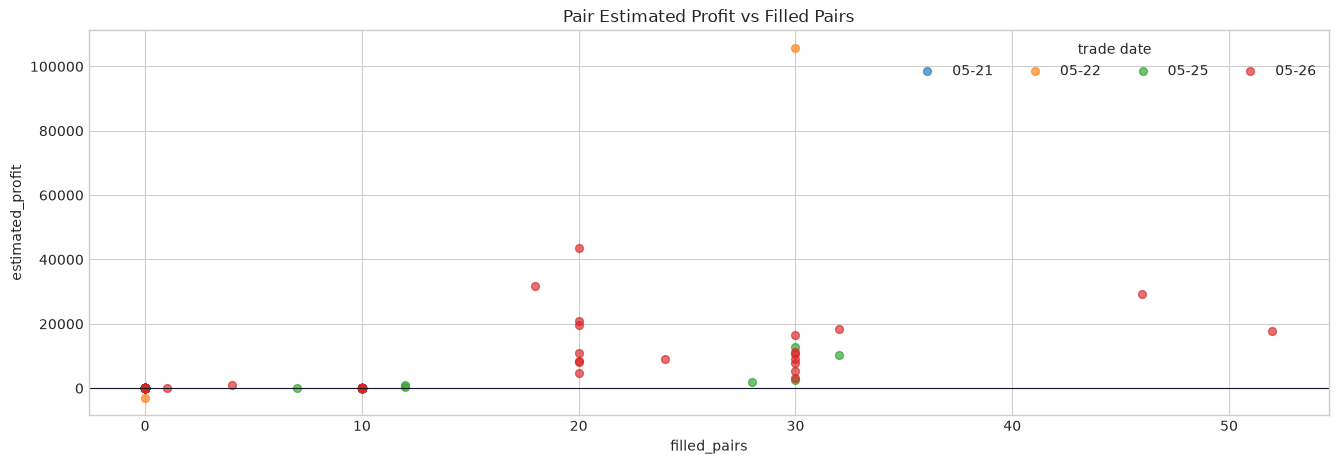

In [23]:
plot_df = pair_profit.copy()
plot_df["date_label"] = pd.to_datetime(plot_df["trade_date"]).dt.strftime("%m-%d")

fig, ax = plt.subplots(figsize=(16, 5))
for date_label, part in plot_df.groupby("date_label"):
    ax.scatter(part["filled_pairs"], part["estimated_profit"], s=32, alpha=0.65, label=date_label)
ax.axhline(0, color="#111827", linewidth=0.8)
ax.set_title("Pair Estimated Profit vs Filled Pairs")
ax.set_xlabel("filled_pairs")
ax.set_ylabel("estimated_profit")
ax.legend(title="trade date", ncols=4)
plt.show()


### __Second-Leg Failure Drill-Down__


In [24]:
failure_outputs = daily_hbt.build_second_leg_failure_outputs(
    summary=summary,
    trades=trades,
    market=market,
    window_rows=10,
)

failure_overview = failure_outputs["failure_overview"]
failed_pairs = failure_outputs["failed_pairs"]
failed_trades = failure_outputs["failed_trades"]
failure_by_date = failure_outputs["failure_by_date"]
failure_by_status = failure_outputs["failure_by_status"]
failure_by_pair = failure_outputs["failure_by_pair"]
failure_trade_windows = failure_outputs["failure_trade_windows"]
failure_market_tick_windows = failure_outputs["failure_market_tick_windows"]

display(failure_overview)

if not failure_by_date.empty:
    display(failure_by_date)

if failure_by_status.empty:
    print("No second-leg failure trade rows found.")
else:
    display(failure_by_status)

if failed_pairs.empty:
    print("No pairs with second_leg_failures in summary.")
else:
    display(failed_pairs.head(50))

if not failure_by_pair.empty:
    display(failure_by_pair.head(50))

print(f"failure_trade_windows rows={len(failure_trade_windows):,}")
print(f"failure_market_tick_windows rows={len(failure_market_tick_windows):,}")


,pairs_with_summary_failures,failure_trade_rows,market_window_rows,trade_dates,pair_names,flatten_count
0,5,5,105,3,5,1.0000


,trade_date,summary_pairs,summary_second_leg_failures,flatten_count,failure_trade_rows
0,2026-05-22,1,1,0,1
1,2026-05-25,1,1,1,1
2,2026-05-26,3,3,0,3


,trade_date,status,failure_reason,rows,pair_names
0,2026-05-22,SECOND_LEG_PROFIT_CHECK_FAILED,second leg profit check failed,1,1
1,2026-05-25,POST_FIRST_FEED_TIMEOUT,post-first feed refresh timeout,1,1
2,2026-05-26,SECOND_LEG_PROFIT_CHECK_FAILED,second leg profit check failed,3,3


,trade_date,run_key,pair_name,spot_symbol,future_symbol,second_leg_failures,flatten_count,post_first_feed_wait,post_first_feed_timeout_ns
74,2026-05-22,2026-05-22::6271_KDFF6,6271_KDFF6,6271,KDFF6,1,0,spot,5000000000
131,2026-05-25,2026-05-25::5425_PEFF6,5425_PEFF6,5425,PEFF6,1,1,spot,5000000000
144,2026-05-26,2026-05-26::1605_CSFF6,1605_CSFF6,1605,CSFF6,1,0,spot,5000000000
179,2026-05-26,2026-05-26::8046_LYFF6,8046_LYFF6,8046,LYFF6,1,0,spot,5000000000
189,2026-05-26,2026-05-26::8150_QUFF6,8150_QUFF6,8150,QUFF6,1,0,spot,5000000000


,trade_date,run_key,pair_name,spot_symbol,future_symbol,status,failure_reason,failure_trade_rows,first_failure_ts,last_failure_ts,second_leg_failures,flatten_count,post_first_feed_wait,post_first_feed_timeout_ns
0,2026-05-22,2026-05-22::6271_KDFF6,6271_KDFF6,6271,KDFF6,SECOND_LEG_PROFIT_CHECK_FAILED,second leg profit check failed,1,1779411641741000000,1779411641741000000,1,0,spot,5000000000
1,2026-05-25,2026-05-25::5425_PEFF6,5425_PEFF6,5425,PEFF6,POST_FIRST_FEED_TIMEOUT,post-first feed refresh timeout,1,1779671014791000000,1779671014791000000,1,1,spot,5000000000
2,2026-05-26,2026-05-26::1605_CSFF6,1605_CSFF6,1605,CSFF6,SECOND_LEG_PROFIT_CHECK_FAILED,second leg profit check failed,1,1779757648596000000,1779757648596000000,1,0,spot,5000000000
3,2026-05-26,2026-05-26::8046_LYFF6,8046_LYFF6,8046,LYFF6,SECOND_LEG_PROFIT_CHECK_FAILED,second leg profit check failed,1,1779768390927000000,1779768390927000000,1,0,spot,5000000000
4,2026-05-26,2026-05-26::8150_QUFF6,8150_QUFF6,8150,QUFF6,SECOND_LEG_PROFIT_CHECK_FAILED,second leg profit check failed,1,1779757254258000000,1779757254258000000,1,0,spot,5000000000


failure_trade_windows rows=82
failure_market_tick_windows rows=105


### __Stuck Cash Flow__

Estimate stock-side cash still tied up after arbitrage entries by subtracting convergence-exit cash recovered from entry cash deployed. This is a stock cash view; futures margin and futures PnL are separate constraints.


In [25]:
cash_roi = daily_hbt.build_cash_roi_outputs(trades, market, records)

stuck_cash_summary = cash_roi["stuck_cash_summary"]
daily_stuck_cash = cash_roi["daily_stuck_cash"]
stuck_cash_by_pair = cash_roi["stuck_cash_by_pair"]
top_stuck_cash_pairs = cash_roi["top_stuck_cash_pairs"]


In [26]:
# stuck_cash_summary

In [27]:
# daily_stuck_cash

In [28]:
# top_stuck_cash_pairs.head(30)

2026-07-06 15:43:59,020 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:59,021 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


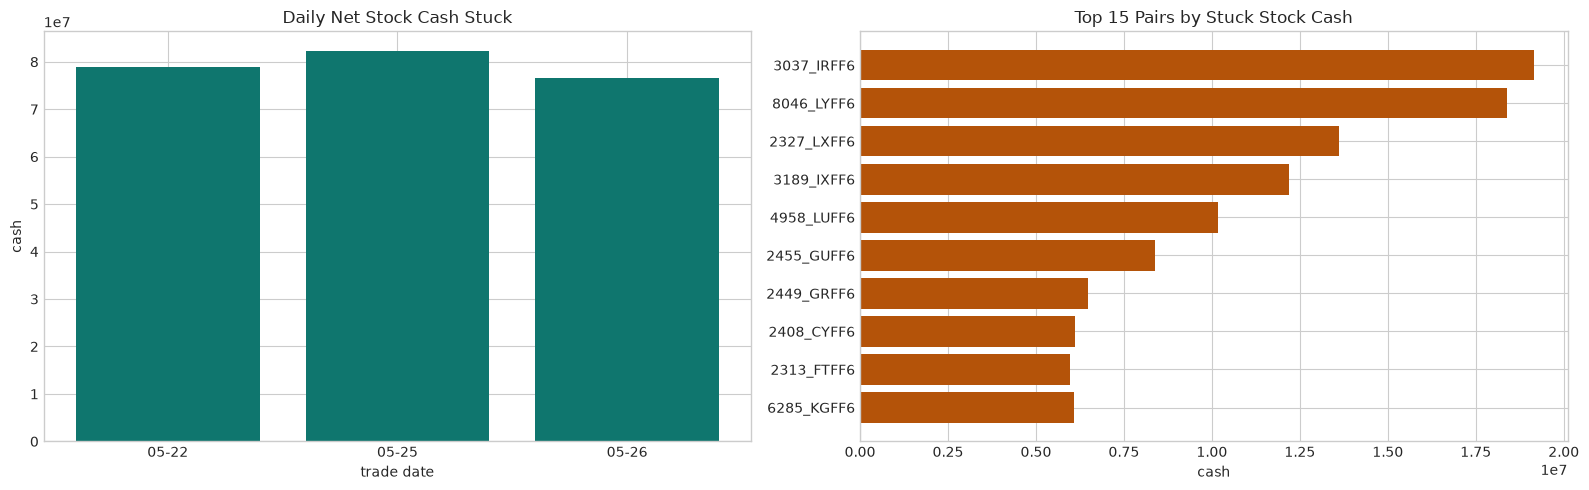

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_daily_cash = daily_stuck_cash.copy()
plot_daily_cash["date_label"] = pd.to_datetime(plot_daily_cash["trade_date"]).dt.strftime("%m-%d")
axes[0].bar(plot_daily_cash["date_label"], plot_daily_cash["net_stock_cash_stuck"], color="#0f766e")
axes[0].set_title("Daily Net Stock Cash Stuck")
axes[0].set_xlabel("trade date")
axes[0].set_ylabel("cash")

plot_top_cash = top_stuck_cash_pairs.head(15).sort_values("net_stock_cash_stuck")
axes[1].barh(plot_top_cash["pair_name"], plot_top_cash["net_stock_cash_stuck"], color="#b45309")
axes[1].set_title("Top 15 Pairs by Stuck Stock Cash")
axes[1].set_xlabel("cash")

fig.tight_layout()
plt.show()

### __ROI Including Open Positions__

Include remaining long-spot / short-future inventory using locked entry spread, not immediate liquidation mark-to-market. Open PnL is estimated from filled entry prices, with stock entry fee plus assumed future stock exit fee/tax deducted.


In [30]:
roi_summary_including_open = cash_roi["roi_summary_including_open"]
daily_roi_including_open = cash_roi["daily_roi_including_open"]
roi_by_pair = cash_roi["roi_by_pair"]
pair_roi_including_open = cash_roi["pair_roi_including_open"]
open_lots = cash_roi["open_lots"]


In [31]:
# roi_summary_including_open

In [32]:
# daily_roi_including_open

In [33]:
# pair_roi_including_open.head(30)

2026-07-06 15:43:59,222 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:59,223 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-07-06 15:43:59,225 INFO Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


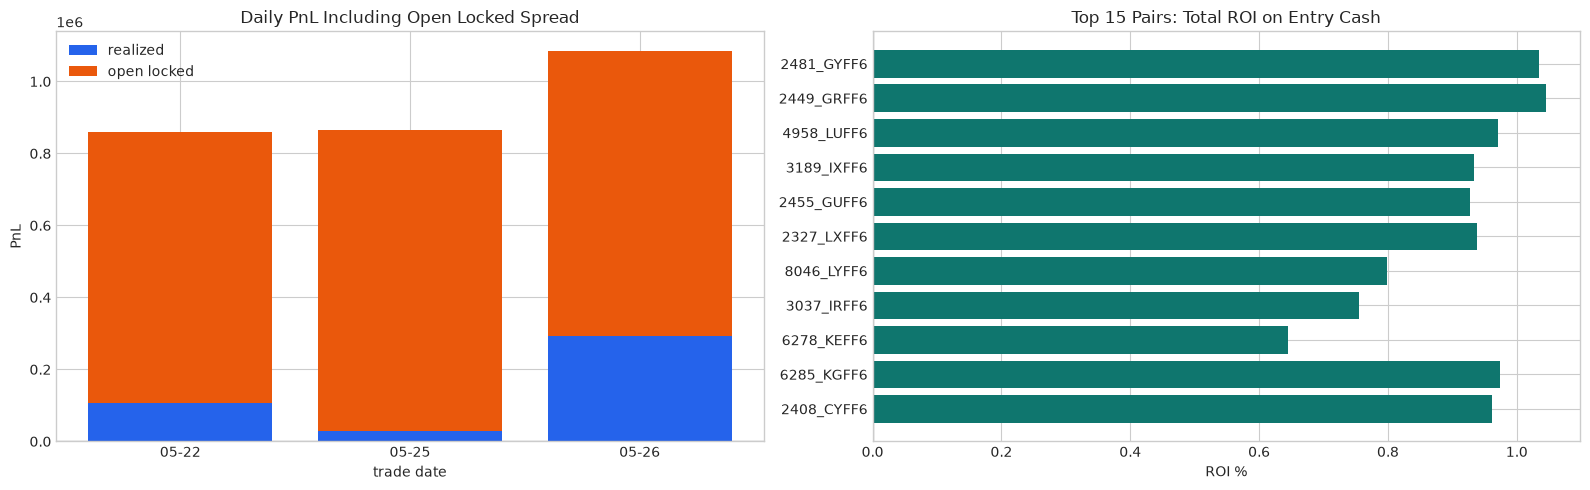

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_daily_roi = daily_roi_including_open.copy()
plot_daily_roi["date_label"] = pd.to_datetime(plot_daily_roi["trade_date"]).dt.strftime("%m-%d")
axes[0].bar(plot_daily_roi["date_label"], plot_daily_roi["realized_pnl"], label="realized", color="#2563eb")
axes[0].bar(
    plot_daily_roi["date_label"],
    plot_daily_roi["open_locked_pnl"],
    bottom=plot_daily_roi["realized_pnl"],
    label="open locked",
    color="#ea580c",
)
axes[0].axhline(0, color="#111827", linewidth=0.8)
axes[0].set_title("Daily PnL Including Open Locked Spread")
axes[0].set_xlabel("trade date")
axes[0].set_ylabel("PnL")
axes[0].legend()

plot_pair_roi = pair_roi_including_open.head(15).sort_values("total_roi_on_entry_cash_pct")
axes[1].barh(plot_pair_roi["pair_name"], plot_pair_roi["total_roi_on_entry_cash_pct"] * 100, color="#0f766e")
axes[1].axvline(0, color="#111827", linewidth=0.8)
axes[1].set_title("Top 15 Pairs: Total ROI on Entry Cash")
axes[1].set_xlabel("ROI %")

fig.tight_layout()
plt.show()


### __Latency Observation__

The long-format `latency` table records the local timeline plus the latest spot/future exchange feed timestamps and order timestamps at each lifecycle event.

> feed 延遲是用 tick data 裡面 local timestamp 與 exchange timestamp 的差值計算出來的。如果需要手動調整 feed 延遲，可以調整 `feed_latency_offset_ms`。


In [35]:
latency_summary = (
    latency
    .groupby(["pair_name", "event_type"], dropna=False)
    .agg(
        rows=("event_type", "size"),
        spot_feed_latency_ms=("spot_feed_latency_ns", lambda s: pd.to_numeric(s, errors="coerce").mean() / 1_000_000),
        future_feed_latency_ms=("future_feed_latency_ns", lambda s: pd.to_numeric(s, errors="coerce").mean() / 1_000_000),
        order_entry_latency_ms=("order_entry_latency_ns", lambda s: pd.to_numeric(s, errors="coerce").mean() / 1_000_000),
        order_response_latency_ms=("order_response_latency_ns", lambda s: pd.to_numeric(s, errors="coerce").mean() / 1_000_000),
    )
    .reset_index()
)

In [36]:

latency_summary.sort_values(["pair_name", "event_type"]).head(60)


,pair_name,event_type,rows,spot_feed_latency_ms,future_feed_latency_ms,order_entry_latency_ms,order_response_latency_ms
0,1303_CAFF6,completion,30,10.0000,10.0000,NaN,NaN
1,1303_CAFF6,first_order_entry,30,10.0000,10.0000,10.0000,10.0000
2,1303_CAFF6,post_first_market,30,10.0000,10.0000,NaN,NaN
3,1303_CAFF6,second_order_entry,30,10.0000,10.0000,10.0000,10.0000
4,1303_CAFF6,signal_market,30,10.0000,10.0000,NaN,NaN
5,1605_CSFF6,completion,41,10.0000,10.0000,NaN,NaN
6,1605_CSFF6,first_order_entry,41,10.0000,10.0000,10.0000,10.0000
7,1605_CSFF6,flatten_first_order,1,10.0000,10.0000,10.0000,10.0000
8,1605_CSFF6,post_first_market,41,10.0000,10.0000,NaN,NaN
9,1605_CSFF6,second_order_entry,40,10.0000,10.0000,10.0000,10.0000


In [37]:
latency_event_counts = latency.value_counts(["event_type", "leg", "side"], dropna=False).reset_index(name="rows")
latency_event_counts


,event_type,leg,side,rows
0,signal_market,NaN,NaN,1117
1,completion,NaN,NaN,1117
2,post_first_market,NaN,NaN,1093
3,first_order_entry,future,sell,849
4,second_order_entry,stock,buy,823
5,first_order_entry,future,buy,268
6,second_order_entry,stock,sell,265
7,flatten_first_order,future,buy,3
8,flatten_first_order,future,sell,2


In [38]:
order_latency_check = latency.loc[latency["order_entry_latency_ns"].notna()].copy()
order_latency_check[["event_type", "leg", "side", "order_entry_latency_ns", "order_response_latency_ns"]].describe(include="all")


,event_type,leg,side,order_entry_latency_ns,order_response_latency_ns
count,2210,2210,2210,"2,210.0000","2,210.0000"
unique,3,2,2,NaN,NaN
top,first_order_entry,future,sell,NaN,NaN
freq,1117,1122,1116,NaN,NaN
mean,NaN,NaN,NaN,"10,000,000.0000","10,000,000.0000"
std,NaN,NaN,NaN,0.0000,0.0000
min,NaN,NaN,NaN,"10,000,000.0000","10,000,000.0000"
25%,NaN,NaN,NaN,"10,000,000.0000","10,000,000.0000"
50%,NaN,NaN,NaN,"10,000,000.0000","10,000,000.0000"
75%,NaN,NaN,NaN,"10,000,000.0000","10,000,000.0000"


In [39]:
SELECTED_PAIR = pair_profit.iloc[0]["pair_name"]

entry_cols = [
    "trade_date", "time", "pair_name", "entry_signal", "row_type", "status",
    "long_spot_short_future_pct", "long_spot_short_future_ticks",
    "short_spot_long_future_pct", "short_spot_long_future_ticks",
    "first_leg", "first_side", "first_exec_price", "first_exec_qty",
    "second_leg", "second_side", "second_exec_price", "second_exec_qty",
    "realized_pnl", "first_to_second_exch_ms",
]

entry_exit_all.loc[entry_exit_all["pair_name"].eq(SELECTED_PAIR), [c for c in entry_cols if c in entry_exit_all.columns]].head(100)


,trade_date,time,pair_name,entry_signal,row_type,status,long_spot_short_future_pct,long_spot_short_future_ticks,short_spot_long_future_pct,short_spot_long_future_ticks,first_leg,first_side,first_exec_price,first_exec_qty,second_leg,second_side,second_exec_price,second_exec_qty,realized_pnl,first_to_second_exch_ms
742,2026-05-22,2026-05-22 09:13:09.102000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_signal,<NA>,0.0134,4.5640,0.0155,-9.4340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
743,2026-05-22,2026-05-22 09:13:09.142000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_execution,FIRST_LEG_UNFILLED,0.0134,4.5640,NaN,NaN,future,sell,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN
744,2026-05-22,2026-05-22 09:13:13.142000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_signal,<NA>,0.0134,4.5620,0.0155,-9.4360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
745,2026-05-22,2026-05-22 09:13:13.207000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_execution,FILLED,0.0134,4.5620,NaN,NaN,future,sell,982.0000,1.0000,stock,buy,969.0000,2.0000,NaN,44.9999
746,2026-05-22,2026-05-22 09:18:24.207000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_execution,RISK_SKIP,0.0136,4.5820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,2026-05-22,2026-05-22 11:04:28.127000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_execution,RISK_SKIP,0.0134,4.5620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
838,2026-05-22,2026-05-22 11:04:29.127000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_execution,RISK_SKIP,0.0134,4.5620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839,2026-05-22,2026-05-22 11:04:29.127000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_signal,<NA>,0.0134,4.5620,0.0155,-9.4360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
840,2026-05-22,2026-05-22 11:04:30.127000+08:00,3037_IRFF6,ENTER_LONG_SPOT_SHORT_FUTURE,entry_execution,RISK_SKIP,0.0134,4.5620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
latency_view = latency.loc[latency["pair_name"].eq(SELECTED_PAIR)].copy()
latency_view["local_time"] = pd.to_datetime(latency_view["local_ts"], unit="ns", utc=True).dt.tz_convert("Asia/Taipei")
latency_view["spot_exch_time"] = pd.to_datetime(latency_view["spot_exch_ts"], unit="ns", utc=True).dt.tz_convert("Asia/Taipei")
latency_view["future_exch_time"] = pd.to_datetime(latency_view["future_exch_ts"], unit="ns", utc=True).dt.tz_convert("Asia/Taipei")

cols = [
    "trade_date", "pair_name", "event_type", "leg", "side", "status",
    "local_time", "spot_exch_time", "future_exch_time",
    "spot_feed_latency_ns", "future_feed_latency_ns",
    "order_req_local_ts", "order_exch_ts", "order_resp_local_ts",
    "order_entry_latency_ns", "order_response_latency_ns",
]
latency_view[[c for c in cols if c in latency_view.columns]].head(120)


,trade_date,pair_name,event_type,leg,side,status,local_time,spot_exch_time,future_exch_time,spot_feed_latency_ns,future_feed_latency_ns,order_req_local_ts,order_exch_ts,order_resp_local_ts,order_entry_latency_ns,order_response_latency_ns
165,2026-05-22,3037_IRFF6,signal_market,NaN,NaN,SIGNAL,2026-05-22 09:13:09.102000+08:00,2026-05-22 09:13:09.075141+08:00,2026-05-22 09:13:09.071000+08:00,10000000,10000000,NaN,NaN,NaN,NaN,NaN
166,2026-05-22,3037_IRFF6,first_order_entry,future,sell,FIRST_ORDER_RESPONSE,2026-05-22 09:13:09.102000+08:00,2026-05-22 09:13:09.116422+08:00,2026-05-22 09:13:09.129000+08:00,10000000,10000000,"1,779,412,389,102,000,128.0000","1,779,412,389,112,000,000.0000","1,779,412,389,121,999,872.0000","10,000,000.0000","10,000,000.0000"
167,2026-05-22,3037_IRFF6,completion,NaN,NaN,FIRST_LEG_UNFILLED,2026-05-22 09:13:09.142000+08:00,2026-05-22 09:13:09.116422+08:00,2026-05-22 09:13:09.129000+08:00,10000000,10000000,NaN,NaN,NaN,NaN,NaN
168,2026-05-22,3037_IRFF6,signal_market,NaN,NaN,SIGNAL,2026-05-22 09:13:13.142000+08:00,2026-05-22 09:13:13.104337+08:00,2026-05-22 09:13:13.069000+08:00,10000000,10000000,NaN,NaN,NaN,NaN,NaN
169,2026-05-22,3037_IRFF6,first_order_entry,future,sell,FIRST_ORDER_RESPONSE,2026-05-22 09:13:13.142000+08:00,2026-05-22 09:13:13.142695+08:00,2026-05-22 09:13:13.069000+08:00,10000000,10000000,"1,779,412,393,142,000,128.0000","1,779,412,393,152,000,000.0000","1,779,412,393,161,999,872.0000","10,000,000.0000","10,000,000.0000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,2026-05-22,3037_IRFF6,post_first_market,NaN,NaN,POST_FIRST_MARKET,2026-05-22 13:20:48.925000+08:00,2026-05-22 13:20:48.914958+08:00,2026-05-22 10:44:30.834000+08:00,10000000,10000000,NaN,NaN,NaN,NaN,NaN
281,2026-05-22,3037_IRFF6,second_order_entry,stock,buy,SECOND_ORDER_RESPONSE,2026-05-22 13:20:48.925000+08:00,2026-05-22 13:20:48.914958+08:00,2026-05-22 10:44:30.834000+08:00,10000000,10000000,"1,779,427,248,924,999,936.0000","1,779,427,248,935,000,064.0000","1,779,427,248,944,999,936.0000","10,000,000.0000","10,000,000.0000"
282,2026-05-22,3037_IRFF6,completion,NaN,NaN,FILLED,2026-05-22 13:20:48.945000+08:00,2026-05-22 13:20:48.914958+08:00,2026-05-22 10:44:30.834000+08:00,10000000,10000000,NaN,NaN,NaN,NaN,NaN
283,2026-05-22,3037_IRFF6,signal_market,NaN,NaN,SIGNAL,2026-05-22 13:20:49.945000+08:00,2026-05-22 13:20:49.720826+08:00,2026-05-22 10:44:30.834000+08:00,10000000,10000000,NaN,NaN,NaN,NaN,NaN


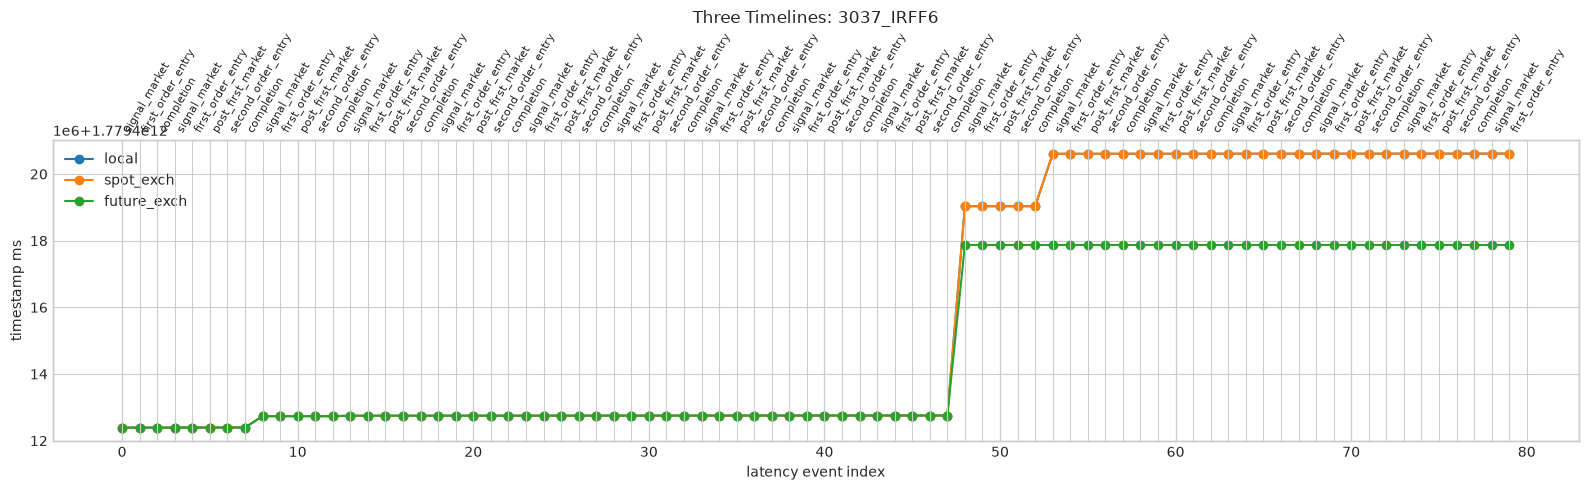

In [41]:
plot_latency = latency_view.head(80).copy().reset_index(drop=True)
if plot_latency.empty:
    print(f"No latency rows for {SELECTED_PAIR}")
else:
    x = plot_latency.index
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(x, plot_latency["local_ts"] / 1_000_000, marker="o", label="local")
    ax.plot(x, plot_latency["spot_exch_ts"] / 1_000_000, marker="o", label="spot_exch")
    ax.plot(x, plot_latency["future_exch_ts"] / 1_000_000, marker="o", label="future_exch")
    ax.set_title(f"Three Timelines: {SELECTED_PAIR}")
    ax.set_xlabel("latency event index")
    ax.set_ylabel("timestamp ms")
    ax.legend()
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(x)
    ax2.set_xticklabels(plot_latency["event_type"], rotation=60, ha="left", fontsize=8)
    fig.tight_layout()
    plt.show()
